<h1>ENSO Index - Ensemble Means</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.datareader import datareader as dr
from src.util import util, stats

import warnings
warnings.filterwarnings('ignore')

<h5>Get data readers</h5>

In [3]:
ufs_experiments = ['baseline', 'beta.0.1', 'c96_beta.0.1', 'cpc_ics']

In [4]:
era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [5]:
ufs_vars_list = ['slp', 'prmsl']
era5_var = 'mean_sea_level_pressure'

In [6]:
era5_data_reader.describe(era5_var)


Variable: mean_sea_level_pressure
Dimensions: ('time', 'lat', 'lon')
Shape: (92044, 256, 512)
Attributes:
  - long_name: Mean sea level pressure
  - short_name: msl
  - standard_name: air_pressure_at_mean_sea_level
  - units: Pa


<h5>Define time period</h5>

In [7]:
time_range = ("1994-01-01", "2021-12-31T23")
initmonths = (11,)

# For NAO, there are 2 reference locations:
region_1 = {'latmin': 37.7, 'lonmin': 334.3}
region_2 = {'latmin': 65.0, 'lonmin': 331.2}

<h5>Get the monthly climatology for nino 3.4</h5>

In [8]:
%%capture captured_output
ufs_ds_1 = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range,
                                  region=region_1, initmonths=initmonths, flatten=True)

ufs_ds_2 = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range,
                                  region=region_2, initmonths=initmonths, flatten=True)

<h5>Get the corresponding ERA5 data</h5>

In [9]:
era5_ds_1 = era5_data_reader.retrieve(var=era5_var,
                lat=region_1['latmin'],
                lon=region_1['lonmin'],
                time=time_range).squeeze(['lat', 'lon'])  # flatten

era5_ds_2 = era5_data_reader.retrieve(var=era5_var,
                lat=region_2['latmin'],
                lon=region_2['lonmin'],
                time=time_range).squeeze(['lat', 'lon'])  # flatten

<h5>Calculate climatology (this may take a couple minutes)</h5>

In [11]:
ufs_stats_1 = stats.calc_climatology_anomaly(ufs_ds_1, area_mean=False, use_member_climatology=True)
ufs_stats_2 = stats.calc_climatology_anomaly(ufs_ds_2, area_mean=False, use_member_climatology=True)

In [12]:
era5_stats_1 = stats.calc_climatology_anomaly(era5_ds_1, area_mean=False)
era5_stats_2 = stats.calc_climatology_anomaly(era5_ds_2, area_mean=False)

<h5>Normalize the data.  z = (X - mu) / sigma</h5>

In [13]:
# Normalize UFS datasets
ufs_da_1 = stats.normalize(da=ufs_ds_1[ufs_vars_list[0]], stats=ufs_stats_1)
ufs_da_2 = stats.normalize(da=ufs_ds_2[ufs_vars_list[0]], stats=ufs_stats_2)

In [14]:
# Normalize VERIF datasets
era5_da_1 = stats.normalize(da=era5_stats_1['monthly_mean'], stats=era5_stats_1)
era5_da_2 = stats.normalize(da=era5_stats_2['monthly_mean'], stats=era5_stats_2)

<h2>Calculate NAO Index</h2>

<h5>Take difference between 2 locations and store result into new datasets</h5>

In [15]:
ufs_ds_diff = (ufs_da_2 - ufs_da_1).to_dataset()
era5_ds_diff = (era5_da_2 - era5_da_1).to_dataset()

<h5>Calculate climatology of these differences(this may take a couple minutes)</h5>

In [16]:
ufs_stats = stats.calc_climatology_anomaly(ufs_ds_diff, area_mean=False, use_member_climatology=True)

In [17]:
era5_stats = stats.calc_climatology_anomaly(era5_ds_diff, area_mean=False)

<h2>Plot SST Index and Anomaly</h2>

Generating 4 panel(s).
Processing years 1994 to 1999
Processing years 2000 to 2009
Processing years 2010 to 2019
Processing years 2020 to 2021


<module 'matplotlib.pyplot' from '/home/thamzey/miniforge2/envs/ufs_py311/lib/python3.11/site-packages/matplotlib/pyplot.py'>

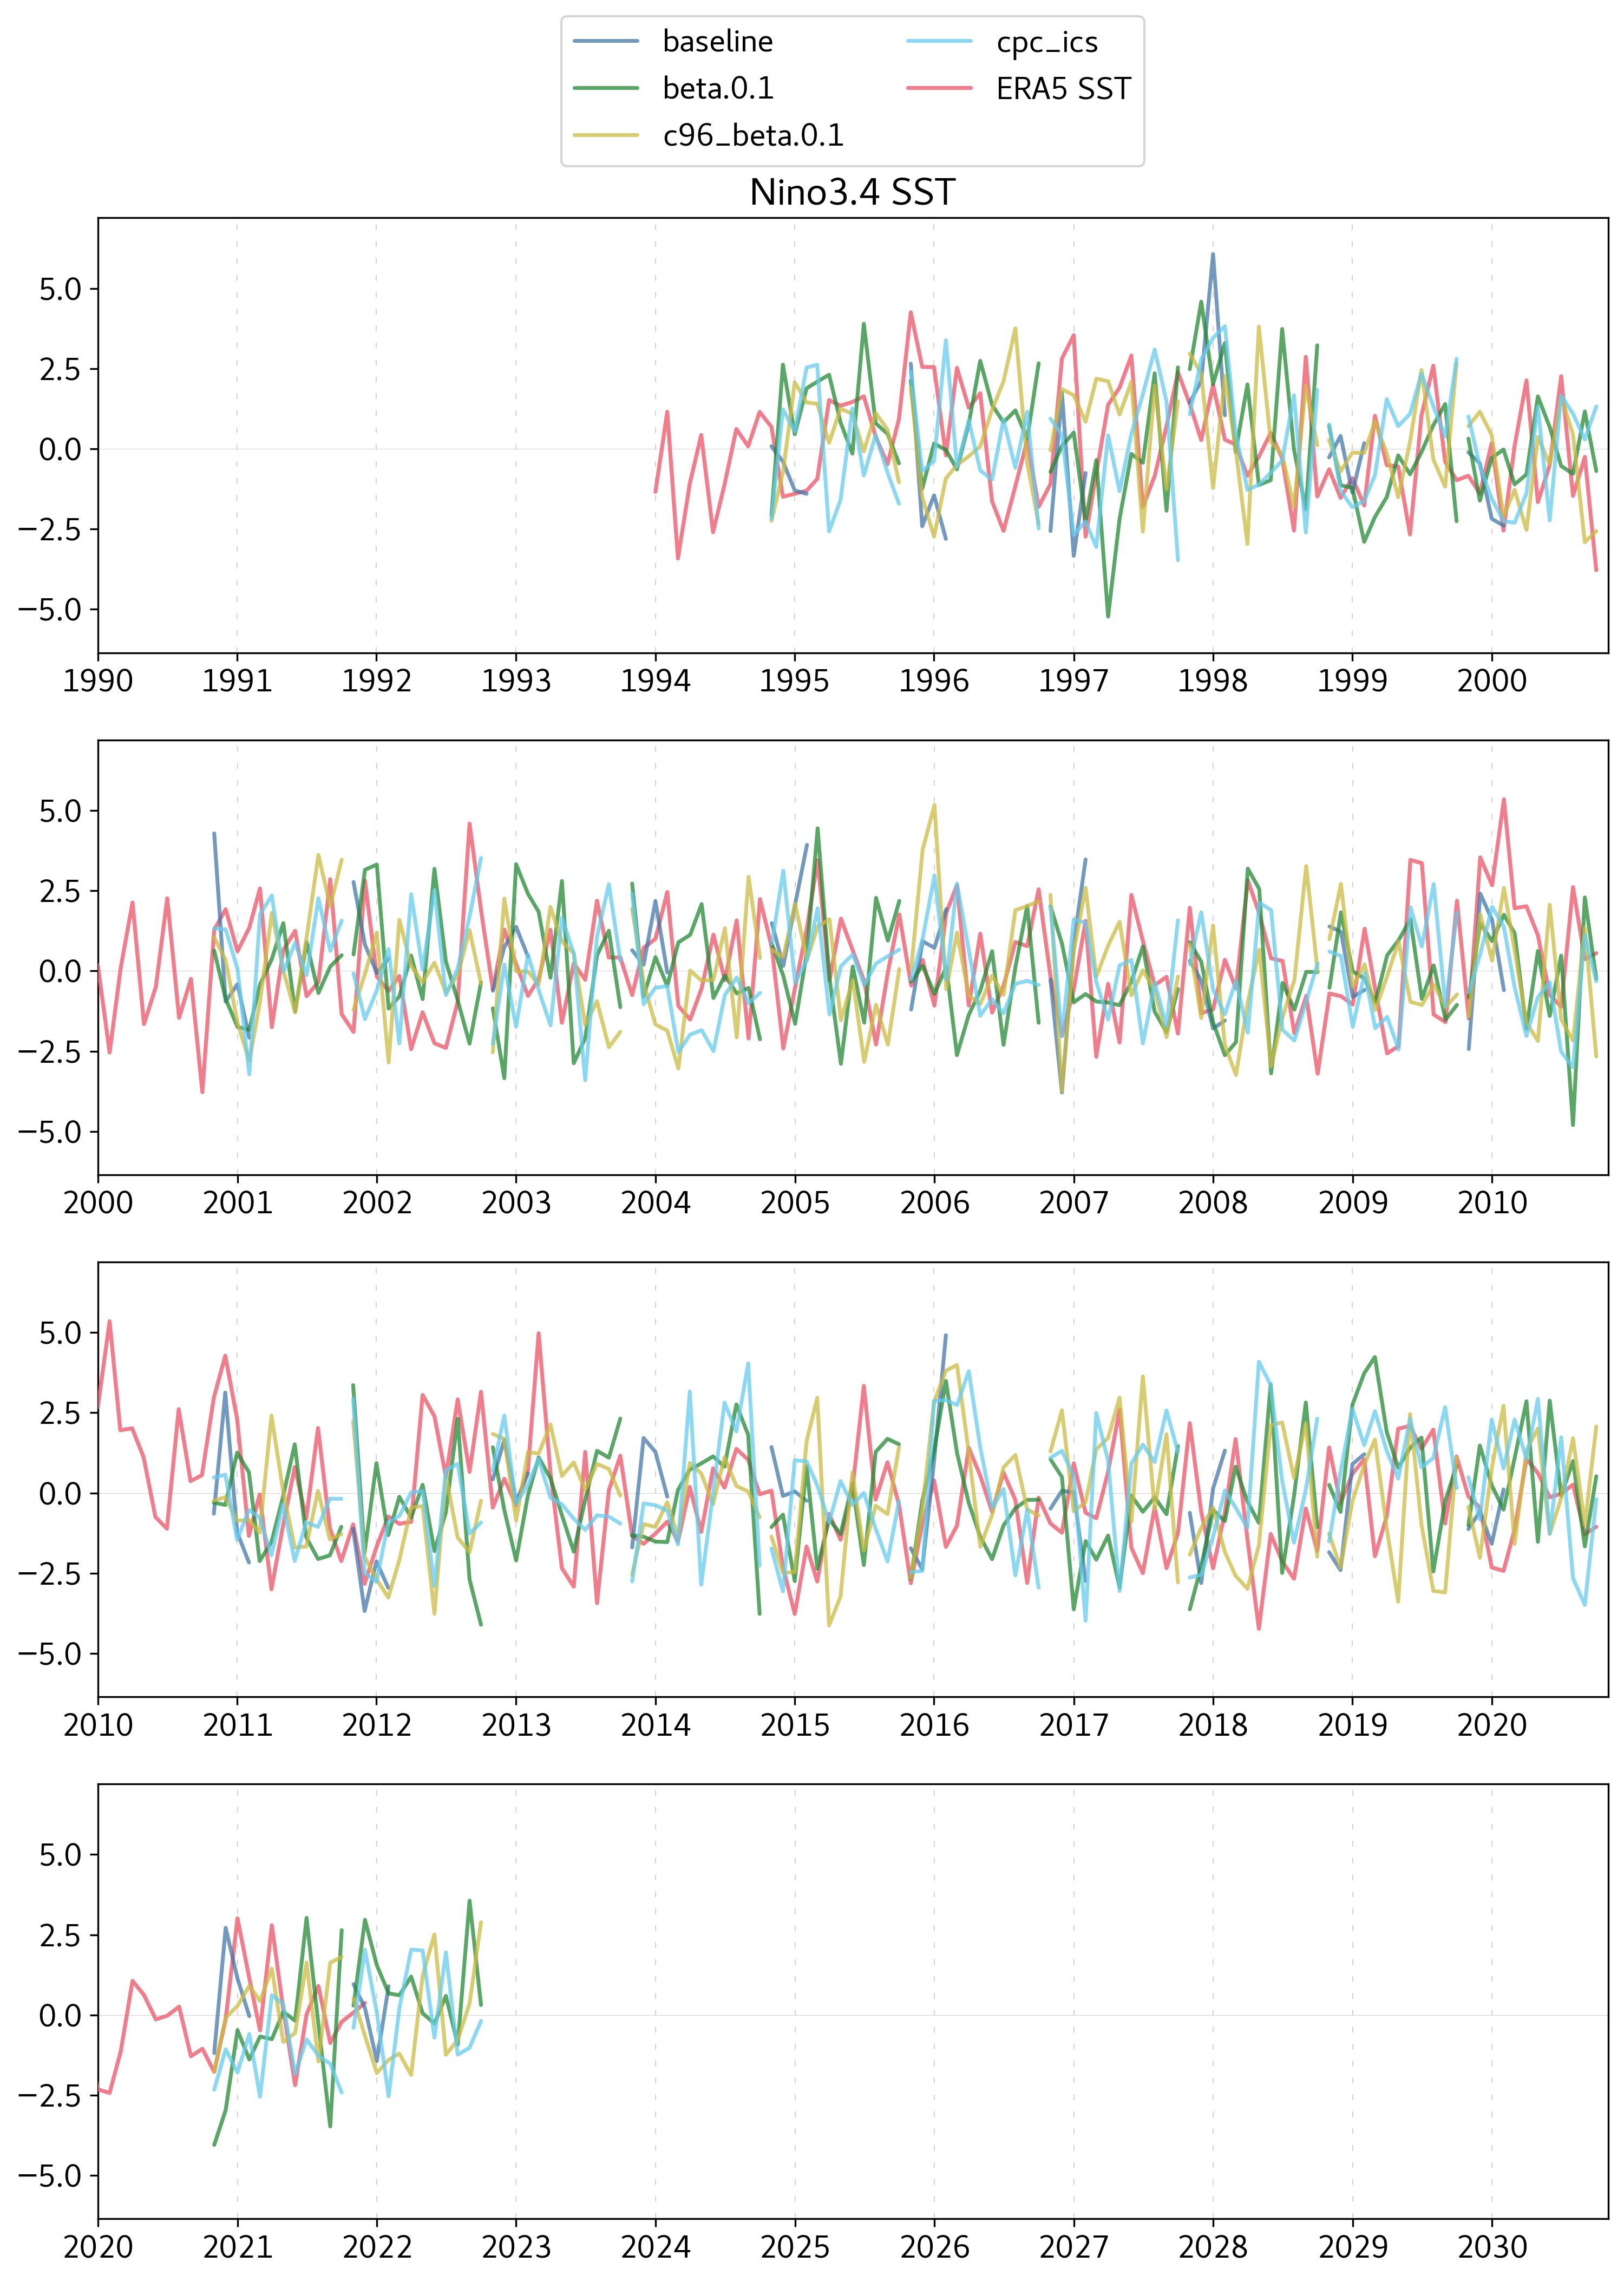

In [18]:
stats.plot_index_spaghetti(ufs_stats=ufs_stats,
                           verif_stats=era5_stats,
                           calc_anomaly=True,
                           title=f'Nino3.4 SST',
                           verif_label='ERA5 SST',
                           dpi=300)